# Loan Default Risk Analysis

An end-to-end analysis of 148,670 mortgage applications. This notebook explores the data, prevents target leakage, compares logistic regression with a random forest, tests model stability, and discovers borrower segments with K-means clustering.

> **Important:** `Status` is treated as the binary outcome used in the source dataset. The model is an educational risk-ranking exercise, not a production lending decision system.

## Part 1: Dataset Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    silhouette_score,
)

from pathlib import Path

DATA_CANDIDATES = [Path('../data/loan_default.csv'), Path('data/loan_default.csv')]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
DATA_URL = 'https://raw.githubusercontent.com/Tantrayoga/loan-default-risk-modeling/refs/heads/main/dataset/Loan_Default.csv'

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
else:
    print('Local dataset not found; loading the public source copy.')
    df = pd.read_csv(DATA_URL)

print('Dataset shape:', df.shape)
print()
print('Columns:')
print(df.columns.tolist())
print()
print('First 5 rows:')
display(df.head())


Dataset shape: (148670, 34)

Columns:
['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']

First 5 rows:


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## Part 2: Preprocessing

### 2.1 Remove ID, constant, and leakage columns

In [3]:
# Drop columns that are not useful for prediction
# ID is just an identifier and year is constant in this dataset.
# We also remove a few leakage columns whose missingness almost gives away the target.
leakage_columns = ['Interest_rate_spread', 'rate_of_interest', 'Upfront_charges']
base_drop_columns = ['ID', 'year']
columns_to_drop = base_drop_columns + leakage_columns

df_model = df.drop(columns=columns_to_drop).copy()

print('Removed columns before modeling:')
print(columns_to_drop)
print('\nReason: the leakage columns had missing-value patterns that were too closely tied to Status, which caused unrealistically perfect performance.')

Removed columns before modeling:
['ID', 'year', 'Interest_rate_spread', 'rate_of_interest', 'Upfront_charges']

Reason: the leakage columns had missing-value patterns that were too closely tied to Status, which caused unrealistically perfect performance.


### 2.2 Separate features and target

In [4]:
# Separate features and target
X = df_model.drop(columns=['Status'])
y = df_model['Status']

print('Target distribution:')
print(y.value_counts())
print('\nTarget proportion (%):')
print((y.value_counts(normalize=True) * 100).round(2))

Target distribution:
Status
0    112031
1     36639
Name: count, dtype: int64

Target proportion (%):
Status
0    75.36
1    24.64
Name: proportion, dtype: float64


### 2.3 Identify numeric and categorical features

In [5]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Number of numeric features:', len(numeric_features))
print('Number of categorical features:', len(categorical_features))
print('\nFirst few numeric features:', numeric_features[:10])
print('First few categorical features:', categorical_features[:10])

Number of numeric features: 7
Number of categorical features: 21

First few numeric features: ['loan_amount', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']
First few categorical features: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only']


### 2.4 Create the train and test split

In [6]:
# Train/test split
# We keep the test set untouched and do cross-validation only on the training portion.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Split sizes:')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

Split sizes:
X_train: (118936, 28)
X_test: (29734, 28)
y_train: (118936,)
y_test: (29734,)


### 2.5 Build the preprocessing pipeline

In [7]:
# Preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessing pipeline created successfully.')

Preprocessing pipeline created successfully.


## Part 3: Exploratory Data Analysis

### 3.1 Look at data types and missing values

In [8]:
# Basic summary information
print('Data types:')
print(df.dtypes)

missing_table = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values('missing_count', ascending=False)

print('\nTop columns with missing values:')
display(missing_table.head(15))

Data types:
ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type  

,missing_count,missing_percent
Upfront_charges,39642,26.66
Interest_rate_spread,36639,24.64
rate_of_interest,36439,24.51
dtir1,24121,16.22
property_value,15098,10.16
LTV,15098,10.16
income,9150,6.15
loan_limit,3344,2.25
approv_in_adv,908,0.61
age,200,0.13


### 3.2 Check leakage in the removed columns

In [9]:
# Show why the original model was suspicious
leakage_check = pd.DataFrame({
    'missing_rate_if_status_0': df.loc[df['Status'] == 0, leakage_columns].isna().mean().round(4),
    'missing_rate_if_status_1': df.loc[df['Status'] == 1, leakage_columns].isna().mean().round(4)
})

print('Leakage check for removed columns:')
display(leakage_check)

Leakage check for removed columns:


,missing_rate_if_status_0,missing_rate_if_status_1
Interest_rate_spread,0.0000,1.0000
rate_of_interest,0.0000,0.9945
Upfront_charges,0.0282,0.9958


### 3.3 Plot the target distribution

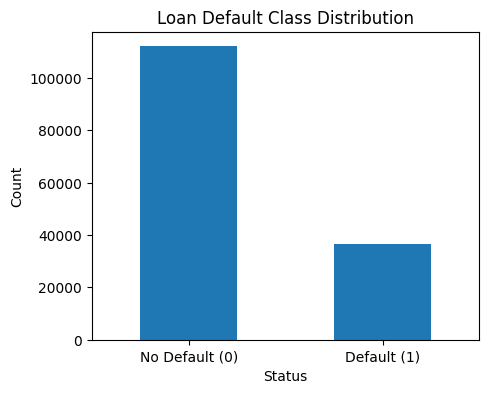

In [10]:
# Target distribution plot
plt.figure(figsize=(5, 4))
y.value_counts().sort_index().plot(kind='bar')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Loan Default Class Distribution')
plt.show()

### 3.4 Plot important numeric feature distributions

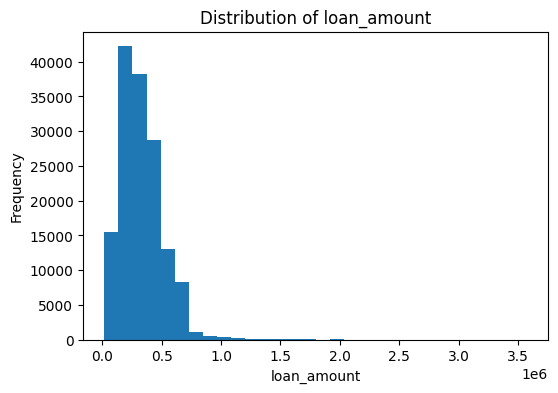

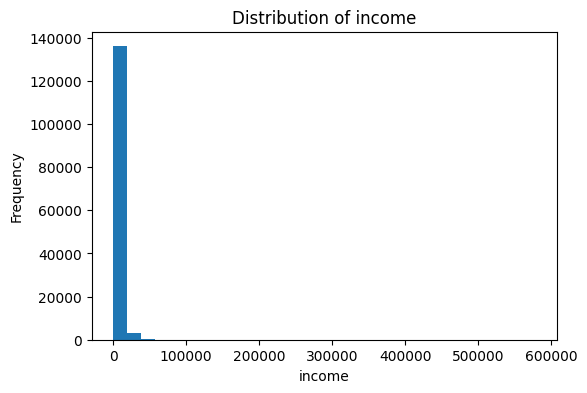

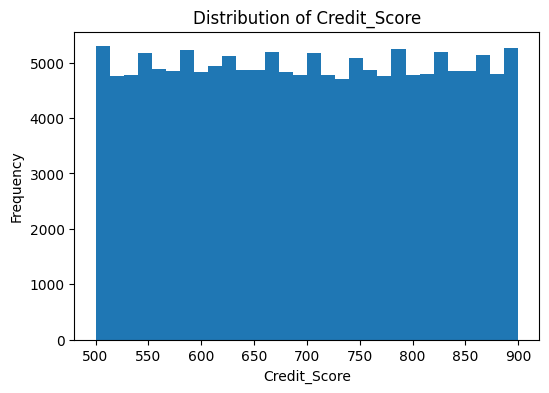

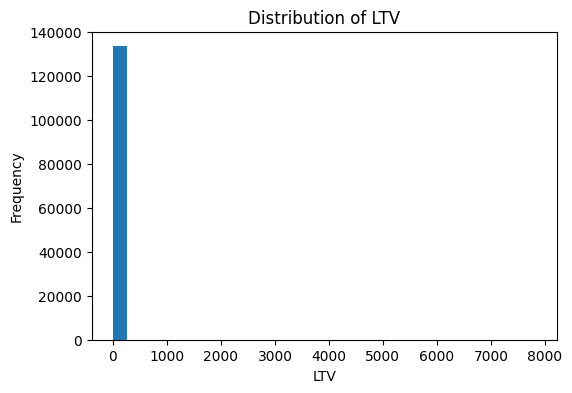

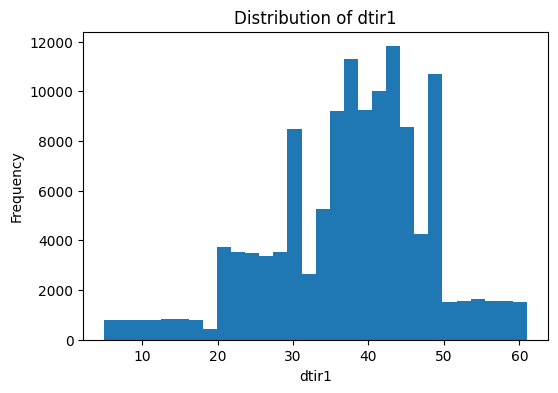

In [11]:
# Numeric feature distributions for a few important variables
important_numeric = ['loan_amount', 'income', 'Credit_Score', 'LTV', 'dtir1']

for col in important_numeric:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

### 3.5 Compare numeric averages by default status

In [12]:
# Compare means by default status for selected numeric columns
available_numeric = [col for col in important_numeric if col in df.columns]
eda_summary = df.groupby('Status')[available_numeric].mean().round(2)

print('Average numeric values by default status:')
display(eda_summary)

Average numeric values by default status:


,loan_amount,income,Credit_Score,LTV,dtir1
Status,,,,,
0,334990.77,7204.01,699.52,72.06,37.37
1,319275.18,6231.81,700.60,76.29,39.60


### 3.6 Compare default rate across categorical features

In [13]:
# Compare default rate by a few categorical columns
for col in ['loan_type', 'loan_purpose', 'credit_type', 'Region']:
    if col in df.columns:
        print(f'\nDefault rate by {col}:')
        rate_table = (
            df.groupby(col)['Status']
            .mean()
            .sort_values(ascending=False)
            .round(3)
        )
        display(rate_table)


Default rate by loan_type:


,Status
loan_type,
type2,0.345
type3,0.251
type1,0.228



Default rate by loan_purpose:


,Status
loan_purpose,
p2,0.331
p1,0.259
p3,0.250
p4,0.230



Default rate by credit_type:


,Status
credit_type,
EQUI,1.000
CRIF,0.162
EXP,0.160
CIB,0.158



Default rate by Region:


,Status
Region,
North-East,0.304
central,0.275
south,0.266
North,0.225


## Part 4: Modeling and Evaluation

**Leakage note:** The first version of the notebook produced near-perfect scores because some columns had missing-value patterns that were almost identical to the target. Those leakage columns were removed before fitting the model.

**Cross-validation note:** We now use **5-fold stratified cross-validation on the training set only**. The test set stays untouched until the end, so the final test result is a cleaner estimate of real performance.


### 4.1 Build the Random Forest pipeline

In [14]:
# Random Forest model trained after removing leakage columns
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

### 4.2 Run 5-fold cross-validation on the training set

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

### 4.3 Show cross-validation results

In [16]:
cv_table = pd.DataFrame({
    'fold': np.arange(1, cv.get_n_splits() + 1),
    'accuracy': cv_results['test_accuracy'],
    'precision': cv_results['test_precision'],
    'recall': cv_results['test_recall'],
    'f1': cv_results['test_f1'],
    'roc_auc': cv_results['test_roc_auc']
})

print('5-Fold Cross-Validation Results (Training Set)')
display(cv_table.round(4))

print('\nCross-validation mean ± std:')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f"{metric}: {cv_table[metric].mean():.4f} ± {cv_table[metric].std():.4f}")

5-Fold Cross-Validation Results (Training Set)


,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.8746,0.7891,0.6706,0.7251,0.8861
1,2,0.8696,0.7810,0.6540,0.7119,0.8786
2,3,0.8722,0.7860,0.6617,0.7185,0.8842
3,4,0.8724,0.7802,0.6714,0.7217,0.8812
4,5,0.8712,0.7814,0.6627,0.7172,0.8812



Cross-validation mean ± std:
accuracy: 0.8720 ± 0.0019
precision: 0.7835 ± 0.0038
recall: 0.6641 ± 0.0072
f1: 0.7189 ± 0.0049
roc_auc: 0.8823 ± 0.0029


### 4.4 Fit the final model on the full training set

In [17]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['loan_amount', 'term',
                                                   'property_value', 'income',
                                                   'Credit_Score', 'LTV',
                                                   'dtir1']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['loan_lim...
                                                   'Neg_ammortization',
                                                   'interest_only',
                                                   'lump_sum_payment',
                                                   'construction_type',
                                                   'occupancy_type',
                                                   'Secured_by', 'total_units',
                                                   'credit_type',
                                                   'co-applicant_credit_type',
                                                   'age',
                                                   'submission_of_application',
                                                   'Region',
                                                   'Security_Type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=3, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

### 4.5 Evaluate on validation and test sets

In [18]:
def evaluate_classifier(name, y_true, y_pred, y_proba):
    print(f'\n{name} Results')
    print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall: {recall_score(y_true, y_pred):.4f}')
    print(f'F1 Score: {f1_score(y_true, y_pred):.4f}')
    print(f'ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}')
    print(f'Classification Report ({name}):')
    print(classification_report(y_true, y_pred))

y_test_pred = rf_pipeline.predict(X_test)
y_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]

evaluate_classifier('Test', y_test, y_test_pred, y_test_proba)


Test Results
Accuracy: 0.8774
Precision: 0.7934
Recall: 0.6793
F1 Score: 0.7320
ROC-AUC: 0.8872
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     22406
           1       0.79      0.68      0.73      7328

    accuracy                           0.88     29734
   macro avg       0.85      0.81      0.83     29734
weighted avg       0.87      0.88      0.87     29734



### 4.6 Plot the confusion matrix and ROC curve

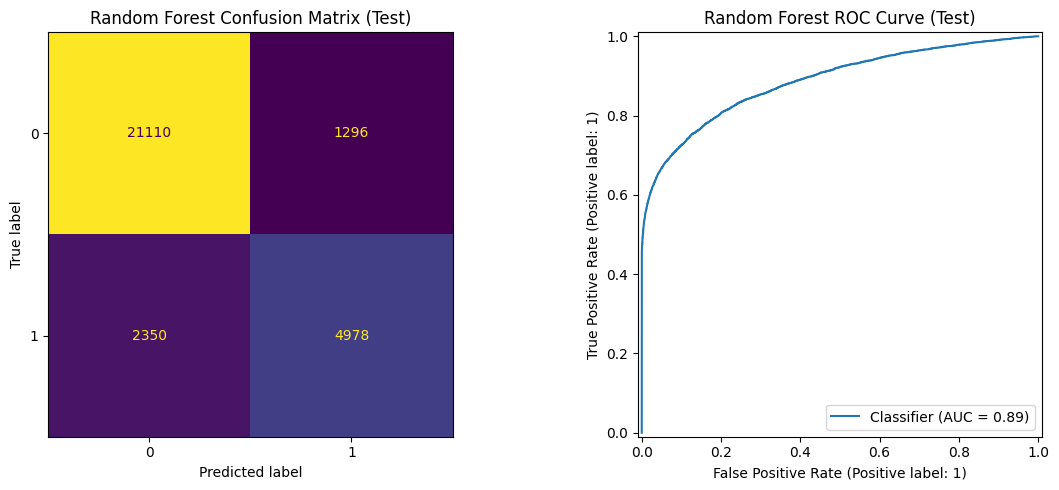

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest Confusion Matrix (Test)')
RocCurveDisplay.from_predictions(y_test, y_test_proba, ax=axes[1])
axes[1].set_title('Random Forest ROC Curve (Test)')
plt.tight_layout()
plt.show()

### 4.7 Show feature importance

In [20]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Top 15 most important features (after removing leakage columns):')
display(importance_df.head(15))

Top 15 most important features (after removing leakage columns):


,feature,importance
47,cat__credit_type_EQUI,0.223646
6,num__dtir1,0.136439
2,num__property_value,0.119131
5,num__LTV,0.113500
3,num__income,0.047309
49,cat__co-applicant_credit_type_CIB,0.024368
28,cat__Neg_ammortization_neg_amm,0.024322
33,cat__lump_sum_payment_not_lpsm,0.022650
45,cat__credit_type_CIB,0.022531
32,cat__lump_sum_payment_lpsm,0.022300


### 4.8 Build the Logistic Regression baseline

In [21]:
numeric_transformer_logreg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_logreg = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_logreg = ColumnTransformer([
    ('num', numeric_transformer_logreg, numeric_features),
    ('cat', categorical_transformer_logreg, categorical_features)
])

logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor_logreg),
    ('model', logreg_model)
])

### 4.9 Run 5-fold cross-validation for the baseline

In [22]:
logreg_cv_results = cross_validate(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

logreg_cv_table = pd.DataFrame({
    'fold': np.arange(1, cv.get_n_splits() + 1),
    'accuracy': logreg_cv_results['test_accuracy'],
    'precision': logreg_cv_results['test_precision'],
    'recall': logreg_cv_results['test_recall'],
    'f1': logreg_cv_results['test_f1'],
    'roc_auc': logreg_cv_results['test_roc_auc']
})

print('5-Fold Cross-Validation Results: Logistic Regression Baseline')
display(logreg_cv_table.round(4))

print('\nLogistic Regression cross-validation mean ± std:')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f"{metric}: {logreg_cv_table[metric].mean():.4f} ± {logreg_cv_table[metric].std():.4f}")

5-Fold Cross-Validation Results: Logistic Regression Baseline


,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.8260,0.6509,0.6345,0.6426,0.8397
1,2,0.8265,0.6549,0.6261,0.6402,0.8338
2,3,0.8265,0.6513,0.6368,0.6440,0.8394
3,4,0.8236,0.6418,0.6430,0.6424,0.8368
4,5,0.8253,0.6487,0.6348,0.6417,0.8336



Logistic Regression cross-validation mean ± std:
accuracy: 0.8256 ± 0.0012
precision: 0.6495 ± 0.0049
recall: 0.6350 ± 0.0061
f1: 0.6421 ± 0.0014
roc_auc: 0.8367 ± 0.0029


### 4.10 Fit and evaluate the Logistic Regression baseline on the test set

In [23]:
logreg_pipeline.fit(X_train, y_train)

y_test_pred_logreg = logreg_pipeline.predict(X_test)
y_test_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

evaluate_classifier('Logistic Regression Baseline (Test)', y_test, y_test_pred_logreg, y_test_proba_logreg)


Logistic Regression Baseline (Test) Results
Accuracy: 0.8314
Precision: 0.6602
Recall: 0.6507
F1 Score: 0.6554
ROC-AUC: 0.8425
Classification Report (Logistic Regression Baseline (Test)):
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     22406
           1       0.66      0.65      0.66      7328

    accuracy                           0.83     29734
   macro avg       0.77      0.77      0.77     29734
weighted avg       0.83      0.83      0.83     29734



### 4.11 Compare Random Forest and Logistic Regression on the test set

In [24]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_logreg),
        accuracy_score(y_test, y_test_pred)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_logreg),
        precision_score(y_test, y_test_pred)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_logreg),
        recall_score(y_test, y_test_pred)
    ],
    'F1 Score': [
        f1_score(y_test, y_test_pred_logreg),
        f1_score(y_test, y_test_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_test_proba_logreg),
        roc_auc_score(y_test, y_test_proba)
    ]
})

print('Test Set Comparison: Logistic Regression Baseline vs Random Forest')
display(comparison_df.round(4))

Test Set Comparison: Logistic Regression Baseline vs Random Forest


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8314,0.6602,0.6507,0.6554,0.8425
1,Random Forest,0.8774,0.7934,0.6793,0.7320,0.8872


### ROC comparison plot

<Figure size 600x500 with 0 Axes>

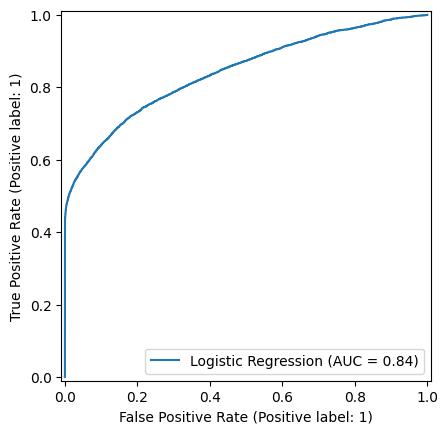

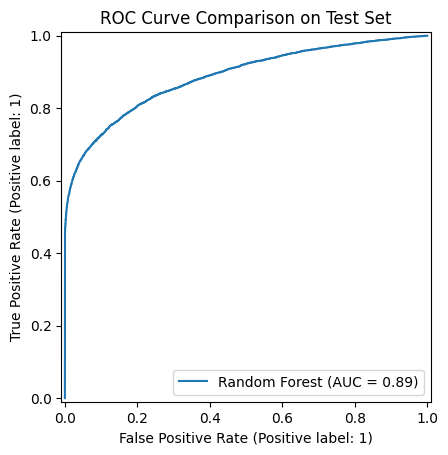

In [25]:
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_test_proba_logreg, name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, y_test_proba, name='Random Forest')
plt.title('ROC Curve Comparison on Test Set')
plt.show()

## Part 5: Simulation Stability Check

This extra section uses repeated stratified train/validation splits on the training set to show whether the Random Forest stays stable across many random splits. This connects to the simulation topic from class.


### 5.1 Set up repeated stratified splits

In [26]:
simulation_splitter = StratifiedShuffleSplit(
    n_splits=10,
    test_size=0.2,
    random_state=42
)
simulation_rows = []

### 5.2 Run the simulation

In [27]:
for split_id, (sim_train_idx, sim_val_idx) in enumerate(simulation_splitter.split(X_train, y_train), start=1):
    X_sim_train = X_train.iloc[sim_train_idx]
    X_sim_val = X_train.iloc[sim_val_idx]
    y_sim_train = y_train.iloc[sim_train_idx]
    y_sim_val = y_train.iloc[sim_val_idx]

    sim_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=3,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

    sim_pipeline.fit(X_sim_train, y_sim_train)
    y_sim_pred = sim_pipeline.predict(X_sim_val)
    y_sim_proba = sim_pipeline.predict_proba(X_sim_val)[:, 1]

    simulation_rows.append({
        'split': split_id,
        'accuracy': accuracy_score(y_sim_val, y_sim_pred),
        'precision': precision_score(y_sim_val, y_sim_pred),
        'recall': recall_score(y_sim_val, y_sim_pred),
        'f1': f1_score(y_sim_val, y_sim_pred),
        'roc_auc': roc_auc_score(y_sim_val, y_sim_proba)
    })

### 5.3 Summarize simulation results

In [28]:
simulation_df = pd.DataFrame(simulation_rows)

print('Simulation Results Across 10 Repeated Splits')
display(simulation_df.round(4))

print('\nSimulation mean ± std:')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f"{metric}: {simulation_df[metric].mean():.4f} ± {simulation_df[metric].std():.4f}")

Simulation Results Across 10 Repeated Splits


,split,accuracy,precision,recall,f1,roc_auc
0,1,0.8697,0.7823,0.6528,0.7117,0.8792
1,2,0.8712,0.7862,0.6554,0.7149,0.8816
2,3,0.8724,0.7865,0.6619,0.7189,0.8828
3,4,0.8702,0.7776,0.6631,0.7158,0.8821
4,5,0.8742,0.7892,0.6680,0.7236,0.8886
5,6,0.8722,0.7825,0.6667,0.7200,0.8832
6,7,0.8719,0.7848,0.6614,0.7178,0.8810
7,8,0.8748,0.7844,0.6784,0.7276,0.8849
8,9,0.8756,0.7919,0.6718,0.7269,0.8841
9,10,0.8707,0.7790,0.6634,0.7166,0.8818



Simulation mean ± std:
accuracy: 0.8723 ± 0.0020
precision: 0.7844 ± 0.0043
recall: 0.6643 ± 0.0075
f1: 0.7194 ± 0.0052
roc_auc: 0.8829 ± 0.0025


### 5.4 Visualize the simulation results

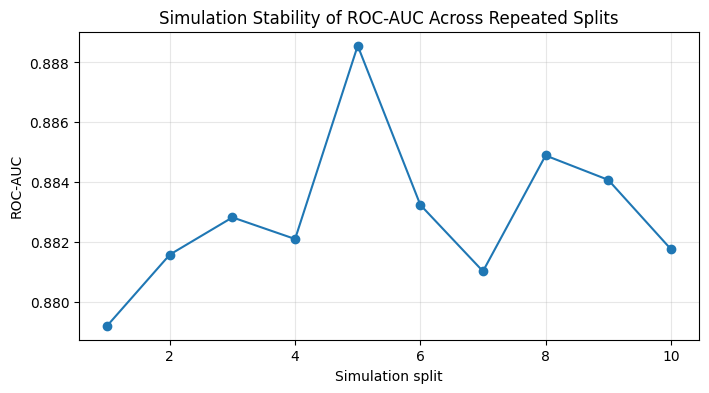

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(simulation_df['split'], simulation_df['roc_auc'], marker='o')
plt.xlabel('Simulation split')
plt.ylabel('ROC-AUC')
plt.title('Simulation Stability of ROC-AUC Across Repeated Splits')
plt.grid(True, alpha=0.3)
plt.show()

## Part 6: Clustering Borrower Segments

This extra section uses clustering only for exploration. We do **not** use `Status` to build the clusters. After forming the clusters, we compare their average feature values and default rates to understand what types of borrowers appear in the data.


### 6.1 Select features for clustering

In [30]:
cluster_features = [
    'loan_amount', 'income', 'Credit_Score', 'LTV', 'dtir1', 'property_value'
]
cluster_features = [col for col in cluster_features if col in df_model.columns]

cluster_frame = df_model[cluster_features].copy()
print('Features used for clustering:')
print(cluster_features)

Features used for clustering:
['loan_amount', 'income', 'Credit_Score', 'LTV', 'dtir1', 'property_value']


### 6.2 Impute and scale the clustering data

In [31]:
cluster_imputer = SimpleImputer(strategy='median')
cluster_scaler = StandardScaler()

cluster_imputed = cluster_imputer.fit_transform(cluster_frame)
cluster_scaled = cluster_scaler.fit_transform(cluster_imputed)

### 6.3 Choose the number of clusters using silhouette score

In [32]:
sample_size = min(10000, len(cluster_scaled))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(cluster_scaled), size=sample_size, replace=False)
cluster_sample = cluster_scaled[sample_idx]

silhouette_rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    sample_labels = km.fit_predict(cluster_sample)
    score = silhouette_score(cluster_sample, sample_labels)
    silhouette_rows.append({'k': k, 'silhouette_score': score})

silhouette_df = pd.DataFrame(silhouette_rows)
display(silhouette_df.round(4))

,k,silhouette_score
0,2,0.9770
1,3,0.2744
2,4,0.2081
3,5,0.2171
4,6,0.2236


### 6.4 Plot silhouette score by k

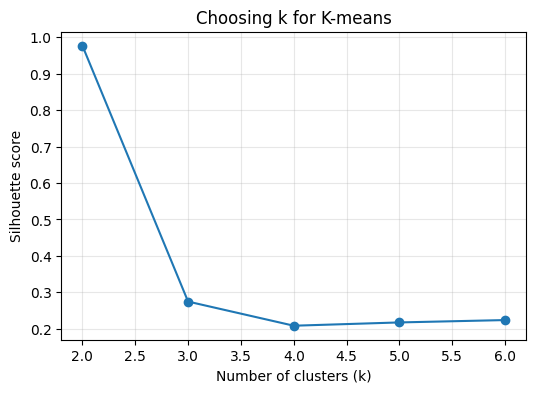

Selected number of clusters: 2


In [33]:
plt.figure(figsize=(6, 4))
plt.plot(silhouette_df['k'], silhouette_df['silhouette_score'], marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Choosing k for K-means')
plt.grid(True, alpha=0.3)
plt.show()

best_k = int(silhouette_df.sort_values('silhouette_score', ascending=False).iloc[0]['k'])
print(f'Selected number of clusters: {best_k}')

### 6.5 Fit K-means with the selected k

In [34]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

cluster_results = cluster_frame.copy()
cluster_results['cluster'] = cluster_labels
cluster_results['Status'] = y.values

### 6.6 Summarize each borrower cluster

In [35]:
cluster_summary = cluster_results.groupby('cluster')[cluster_features].mean().round(2)
cluster_counts = cluster_results['cluster'].value_counts().sort_index().rename('count')
cluster_default_rates = cluster_results.groupby('cluster')['Status'].mean().rename('default_rate').round(4)

print('Cluster summary (average feature values):')
display(cluster_summary)

print('Cluster counts and default rates:')
display(pd.concat([cluster_counts, cluster_default_rates], axis=1))

Cluster summary (average feature values):


,loan_amount,income,Credit_Score,LTV,dtir1,property_value
cluster,,,,,,
0,245878.83,5048.19,699.64,74.70,38.72,342559.43
1,539168.72,11560.14,700.15,68.25,35.50,856321.41


Cluster counts and default rates:


,count,default_rate
cluster,,
0,105462,0.2740
1,43208,0.1792


### 6.7 Visualize borrower clusters with PCA

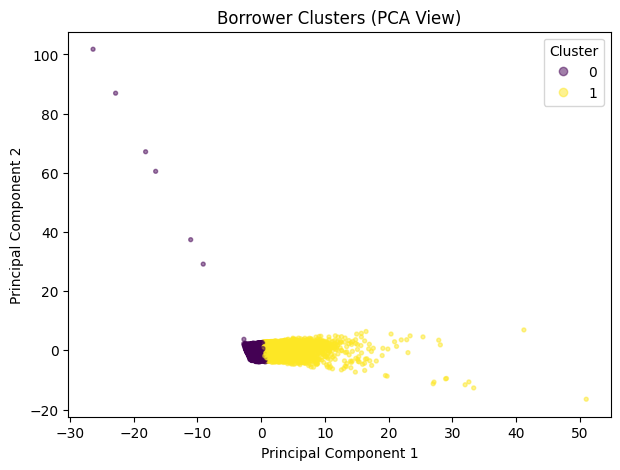

In [36]:
pca = PCA(n_components=2, random_state=42)
cluster_pca = pca.fit_transform(cluster_scaled)

pca_plot_df = pd.DataFrame({
    'PC1': cluster_pca[:, 0],
    'PC2': cluster_pca[:, 1],
    'cluster': cluster_labels
})

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pca_plot_df['PC1'],
    pca_plot_df['PC2'],
    c=pca_plot_df['cluster'],
    s=8,
    alpha=0.5
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Borrower Clusters (PCA View)')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()